In [2]:
%load_ext autoreload
%autoreload 2

from trees.data import Data
from trees.scanners import *
from trees.causal_forest import CF

D = Data()
D.generate()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,ITE,id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,0.002523,-0.001684,-0.008669,-0.007690,0.012437,0.002649,0.012918,0.001693,0.001131,-0.005640,1.437047,0.502100,0.806172,4999.50000
std,1.022027,0.992098,1.003031,0.992401,0.998175,1.001443,1.010710,1.001298,0.995909,0.991762,3.290630,0.500021,1.158088,2886.89568
min,-4.295391,-4.465604,-3.940008,-3.631539,-3.856375,-3.726141,-4.462969,-3.601085,-3.419906,-4.157734,-12.041417,0.000000,-4.157076,0.00000
25%,-0.685254,-0.670339,-0.684620,-0.673858,-0.661041,-0.671775,-0.661183,-0.684996,-0.677070,-0.680137,-0.768118,0.000000,0.030921,2499.75000
50%,0.007853,-0.017794,-0.014492,0.005256,0.012248,0.009466,0.017331,0.001488,0.003151,0.003104,1.399103,1.000000,0.786993,4999.50000
75%,0.686816,0.666640,0.664414,0.657044,0.690269,0.676462,0.698700,0.672743,0.672574,0.674684,3.573415,1.000000,1.559871,7499.25000
max,3.727833,3.942331,3.829782,4.479084,3.594374,3.926238,3.602832,3.712795,3.605591,3.852731,14.667230,1.000000,6.516317,9999.00000


In [3]:
cf = CF(greedy_scanners[0])
cf.fit(D=D)

100%|██████████| 6008/6008 [00:26<00:00, 227.21it/s] 


In [4]:
important_features = []
for i, fi in enumerate(cf.forest.feature_importances_):
    if fi > 0:
        print(D.df.columns[i], round(fi,5))
        important_features.append(i)

feature_0 0.90782
feature_1 0.09218


In [5]:
D.generate_random_condition()

User condition: feature_5 <= 0.665 Selectivity: 0.7458


('feature_5 <= 0.665', 0.7458)

In [6]:
cf.online()
print("Total options:", len(cf.options), "Valid options:", len(cf.valid_options))

Pruned due to min rows: 0
Pruned due to not being subsets: 0
Total options: 6008 Valid options: 6008


In [7]:
scan = greedy_scanners[0](valid_subs=cf.valid_options, op_matrix=cf.op_matrix, D=D)
top = scan.get_topK()
top


,id,condition,combined,features,t_est,depth,algorithm,rows,total_options,validate_time,t,scan_method,scan_time,valid_options,overlap,score
0,3865,feature_0 > -0.962 AND feature_0 > 0.101 AND f...,"{'feature_0': (1.807, 3.728), 'feature_1': (-4...",2,5.283,5,CF (ConstrainedJ),141,6008,1.07,2.622,ConstrainedJ,0.002,6008,0.041756,0.979122
1,2815,feature_0 <= 0.418 AND feature_1 > -0.068 AND ...,"{'feature_0': (0.239, 0.418), 'feature_1': (-0...",2,5.224,5,CF (ConstrainedJ),174,6008,1.07,1.245,ConstrainedJ,0.002,6008,0.019280,0.984776
2,4966,feature_0 > 0.107 AND feature_1 > -0.994 AND f...,"{'feature_0': (0.933, 1.199), 'feature_1': (0....",2,5.208,6,CF (ConstrainedJ),155,6008,1.07,2.509,ConstrainedJ,0.002,6008,0.126043,0.929880
3,4052,feature_0 > 0.276 AND feature_0 > 1.958 AND fe...,"{'feature_0': (1.958, 2.207)}",1,4.854,3,CF (ConstrainedJ),114,6008,1.07,2.918,ConstrainedJ,0.002,6008,0.032955,0.942921
4,844,feature_0 > -0.163 AND feature_0 <= 1.96 AND f...,"{'feature_0': (1.298, 1.96), 'feature_1': (0.8...",2,4.633,7,CF (ConstrainedJ),115,6008,1.07,3.203,ConstrainedJ,0.002,6008,0.122399,0.877282


## Derive a single tree with SingleTreeCateInterpreter

In [8]:
%load_ext autoreload
%autoreload 2

from trees.data import Data
from trees.scanners import *
from trees.causal_forest import CFT

D = Data()
D.generate()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,outcome,treatment,ITE,id
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,0.002523,-0.001684,-0.008669,-0.007690,0.012437,0.002649,0.012918,0.001693,0.001131,-0.005640,1.437047,0.502100,0.806172,4999.50000
std,1.022027,0.992098,1.003031,0.992401,0.998175,1.001443,1.010710,1.001298,0.995909,0.991762,3.290630,0.500021,1.158088,2886.89568
min,-4.295391,-4.465604,-3.940008,-3.631539,-3.856375,-3.726141,-4.462969,-3.601085,-3.419906,-4.157734,-12.041417,0.000000,-4.157076,0.00000
25%,-0.685254,-0.670339,-0.684620,-0.673858,-0.661041,-0.671775,-0.661183,-0.684996,-0.677070,-0.680137,-0.768118,0.000000,0.030921,2499.75000
50%,0.007853,-0.017794,-0.014492,0.005256,0.012248,0.009466,0.017331,0.001488,0.003151,0.003104,1.399103,1.000000,0.786993,4999.50000
75%,0.686816,0.666640,0.664414,0.657044,0.690269,0.676462,0.698700,0.672743,0.672574,0.674684,3.573415,1.000000,1.559871,7499.25000
max,3.727833,3.942331,3.829782,4.479084,3.594374,3.926238,3.602832,3.712795,3.605591,3.852731,14.667230,1.000000,6.516317,9999.00000


100%|██████████| 392/392 [00:00<00:00, 3187.56it/s]


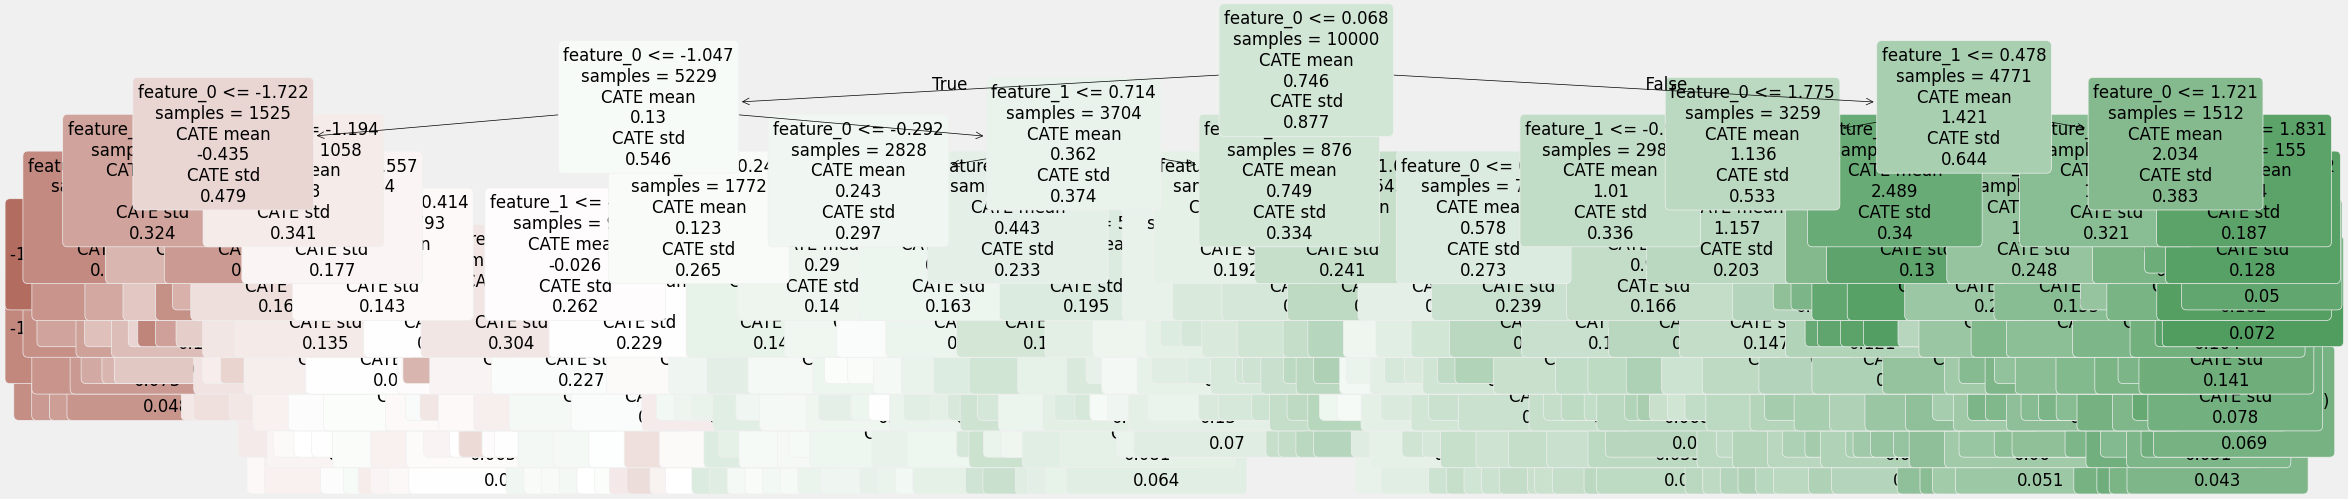

In [11]:
cf = CFT(greedy_scanners[0])
cf.fit(D=D, print_tree=True)

In [12]:
D.generate_random_condition()

User condition: feature_7 <= -0.083 Selectivity: 0.4648


('feature_7 <= -0.083', 0.4648)

In [13]:
cf.online()
print("Total options:", len(cf.options), "Valid options:", len(cf.valid_options))

Pruned due to min rows: 0
Pruned due to not being subsets: 0
Total options: 392 Valid options: 392


In [14]:
scan = greedy_scanners[0](valid_subs=cf.valid_options, op_matrix=cf.op_matrix, D=D)
top = scan.get_topK()
top


,id,condition,combined,features,t_est,depth,algorithm,rows,total_options,validate_time,t,scan_method,scan_time,valid_options,overlap,score
0,390,feature_0 > 0.068 AND feature_1 > 0.478 AND fe...,"{'feature_0': (2.099, 3.728), 'feature_1': (0....",2,2.891,6,CF SingleTree (ConstrainedJ),25,392,0.08,3.718,ConstrainedJ,0.0,392,0.367967,0.816017
1,324,feature_0 > 0.068 AND feature_1 <= 0.478 AND f...,"{'feature_0': (2.186, 3.728), 'feature_1': (-0...",2,2.851,6,CF SingleTree (ConstrainedJ),26,392,0.08,3.253,ConstrainedJ,0.0,392,0.368162,0.809001
2,389,feature_0 > 0.068 AND feature_1 > 0.478 AND fe...,"{'feature_0': (1.831, 2.099), 'feature_1': (0....",2,2.735,6,CF SingleTree (ConstrainedJ),16,392,0.08,3.233,ConstrainedJ,0.0,392,0.172535,0.886752
3,323,feature_0 > 0.068 AND feature_1 <= 0.478 AND f...,"{'feature_0': (1.964, 2.186), 'feature_1': (-0...",2,2.713,6,CF SingleTree (ConstrainedJ),30,392,0.08,2.732,ConstrainedJ,0.0,392,0.178842,0.879794
4,321,feature_0 > 0.068 AND feature_1 <= 0.478 AND f...,"{'feature_0': (2.184, 3.728), 'feature_1': (-4...",2,2.652,6,CF SingleTree (ConstrainedJ),25,392,0.08,2.855,ConstrainedJ,0.0,392,0.243457,0.836936
